# PoC: Compatibilidad Stage 1 y 2


In [31]:
import sys
from pathlib import Path

# Agregar la raíz del código fuente para permitir la importación de 'darl'
# sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darl.data.get_dataset import load_dataset
from darl.utils.beta_dist import beta_distribution
from darl.visualization.plots import plot_beta_distributions, save_plot_to_figures

## Carga de dataset de Physionet

El dataset de Physionet contiene registros de pacientes con diferentes variables fisiológicas. A continuación, se realiza una exploración inicial para entender la estructura del dataset y las características de las variables.


In [2]:
dset = load_dataset(dataset_name="physionet")
print("Done")

c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(
c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(


Done


In [3]:
print("=" * 70)
print("INFORMACION DEL DATASET")
print("=" * 70)
print(f"Nombre: {dset.name}")
print(f"Objetivo: {dset.target}")
print(
    f"Variables predictoras ({len(dset.feature_names) if dset.feature_names else 0}):"
)

vars = sorted(dset.feature_names if dset.feature_names else [])
for var in vars:
    print(f"  - {var}")

print(f"Variables de grupo: {dset.group_feature_names}")
print(f"Etiqueta de dominio: {dset.domain_label_colname}")
print(f"Preprocesador: {dset.preprocessor_config}")
print(f"Separador: {dset.splitter}")
print("Tamanos de los splits:")

if dset.splits is not None:
    for split_name, split_indices in dset.splits.items():
        print(f"  - {split_name}: {len(split_indices):,} filas")

INFORMACION DEL DATASET
Nombre: physionet
Objetivo: SepsisLabel
Variables predictoras (40):
  - AST
  - Age
  - Alkalinephos
  - BUN
  - BaseExcess
  - Bilirubin_direct
  - Bilirubin_total
  - Calcium
  - Chloride
  - Creatinine
  - DBP
  - EtCO2
  - FiO2
  - Fibrinogen
  - Gender
  - Glucose
  - HCO3
  - HR
  - Hct
  - Hgb
  - HospAdmTime
  - Lactate
  - MAP
  - Magnesium
  - O2Sat
  - PTT
  - PaCO2
  - Phosphate
  - Platelets
  - Potassium
  - Resp
  - SBP
  - SaO2
  - Temp
  - TroponinI
  - Unit1
  - Unit2
  - WBC
  - pH
  - set
Variables de grupo: []
Etiqueta de dominio: ICULOS
Preprocesador: PreprocessorConfig(categorical_features='passthrough', numeric_features='passthrough', domain_labels='label_encode', passthrough_columns=None, dropna='all', use_extended_names=False, map_targets=False, cast_targets_to_default_type=False, min_frequency=None, max_categories=None, n_bins=5, sub_illegal_chars=True)
Separador: DomainSplitter(val_size=0.1, random_state=264738, id_test_size=0.1, doma

## Exploración

`SPLIT = ["train", "validation", "id_test", "ood_test", "ood_validation"]`

Al llamar a `dset.get_pandas(split=SPLIT)`, se obtienen los splits de entrenamiento, validación, prueba in-distribution y prueba out-of-distribution.

1. `X`: DataFrame con las variables predictoras (features).
2. `y`: Series con la variable objetivo (target).
3. `g`: (group features) son columnas que identifican subgrupos para evaluar equidad o rendimiento por grupo, por ejemplo sexo, raza o edad agrupada. En tu PhysioNet, group_feature_names=[], así que G está vacío.
4. `d`: (domain label) identifica el dominio de cada fila: se usa para separar datos ID y OOD. En PhysioNet es ICULOS, la duración de estancia en UCI. TableShift usa esa columna para formar los splits de distribución original y desplazada.


In [4]:
X_train, y_train, g_train, d_train = dset.get_pandas(split="train")
X_test, y_test, g_test, d_test = dset.get_pandas(split="id_test")

In [5]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("g_train shape:", g_train.shape)

X_train shape: (1122299, 40)
y_train shape: (1122299,)
g_train shape: (1122299, 0)


### Variables numéricas y categóricas


In [7]:
def split_feature_types(df: pd.DataFrame, cardinality_threshold: int = 20):
    """Separate continuous numeric, ordinal numeric, and categorical columns."""
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    continuous_cols = [
        col
        for col in numeric_cols
        if df[col].nunique(dropna=True) > cardinality_threshold
    ]
    ordinal_cols = [
        col
        for col in numeric_cols
        if df[col].nunique(dropna=True) <= cardinality_threshold
    ]

    return continuous_cols, ordinal_cols, categorical_cols


continuous_cols, ordinal_cols, categorical_cols = split_feature_types(X_train)

print(f"Continuas numericas ({len(continuous_cols)}):")

for col in continuous_cols:
    print(f"  - {col}")

print(f"Ordinales numericas ({len(ordinal_cols)}):")
for col in ordinal_cols:
    print(f"  - {col}")

print(f"Categoricas ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")

Continuas numericas (36):
  - HR
  - O2Sat
  - Temp
  - SBP
  - MAP
  - DBP
  - Resp
  - EtCO2
  - BaseExcess
  - HCO3
  - FiO2
  - pH
  - PaCO2
  - SaO2
  - AST
  - BUN
  - Alkalinephos
  - Calcium
  - Chloride
  - Creatinine
  - Bilirubin_direct
  - Glucose
  - Lactate
  - Magnesium
  - Phosphate
  - Potassium
  - Bilirubin_total
  - TroponinI
  - Hct
  - Hgb
  - PTT
  - WBC
  - Fibrinogen
  - Platelets
  - Age
  - HospAdmTime
Ordinales numericas (3):
  - Gender
  - Unit1
  - Unit2
Categoricas (1):
  - set


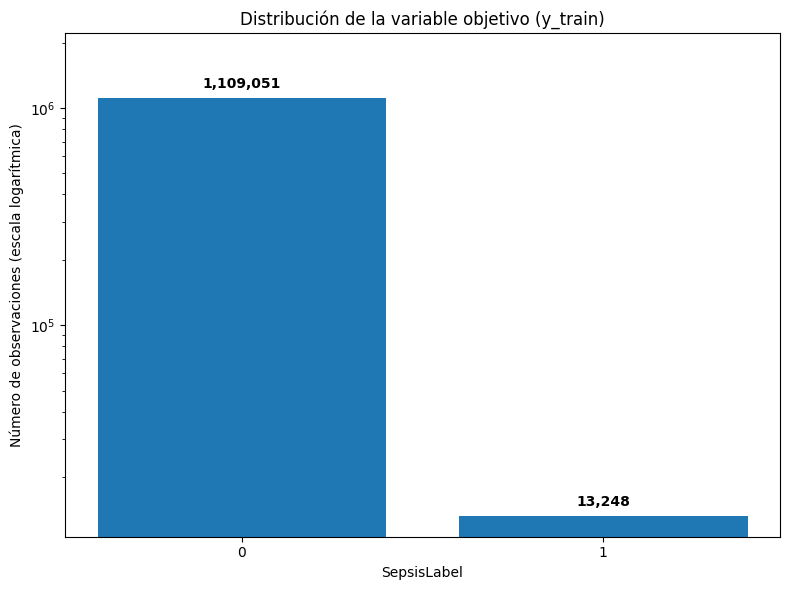

In [ ]:
target_counts = y_train.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(target_counts.index, target_counts.values)
ax.set_yscale("log")
ax.set_title("Distribución de la variable objetivo (y_train)")
ax.set_ylabel("Número de observaciones (escala logarítmica)")
ax.set_xlabel("SepsisLabel")
ax.set_xticks(target_counts.index)
ax.set_xticklabels(target_counts.index.astype(str))
ax.set_ylim(top=target_counts.max() * 2)
ax.bar_label(
    bars,
    labels=[f"{count:,}" for count in target_counts],
    padding=5,
    fontsize=10,
    fontweight="bold",
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1},
)
fig.tight_layout()

### Resumen de Disponibilidad de Variables


In [21]:
numeric_columns = set(X_train.select_dtypes(include="number").columns)
variable_summary = X_train.notna().sum().to_frame("Observaciones no nulas")
variable_summary["% disponibilidad"] = round(
    variable_summary["Observaciones no nulas"] / len(X_train) * 100, 2
)
numeric_data = X_train.select_dtypes(include="number")
variable_summary["Tipo"] = [
    "num" if column in numeric_columns else "cat" for column in variable_summary.index
]
variable_summary.rename_axis("Variable").sort_values(
    "% disponibilidad", ascending=False
)

,Observaciones no nulas,% disponibilidad,Tipo
Variable,,,
set,1122299,100.00,cat
HospAdmTime,1122292,100.00,num
Age,1122299,100.00,num
Gender,1122299,100.00,num
HR,1008302,89.84,num
MAP,979023,87.23,num
O2Sat,972253,86.63,num
SBP,957004,85.27,num
Resp,947102,84.39,num


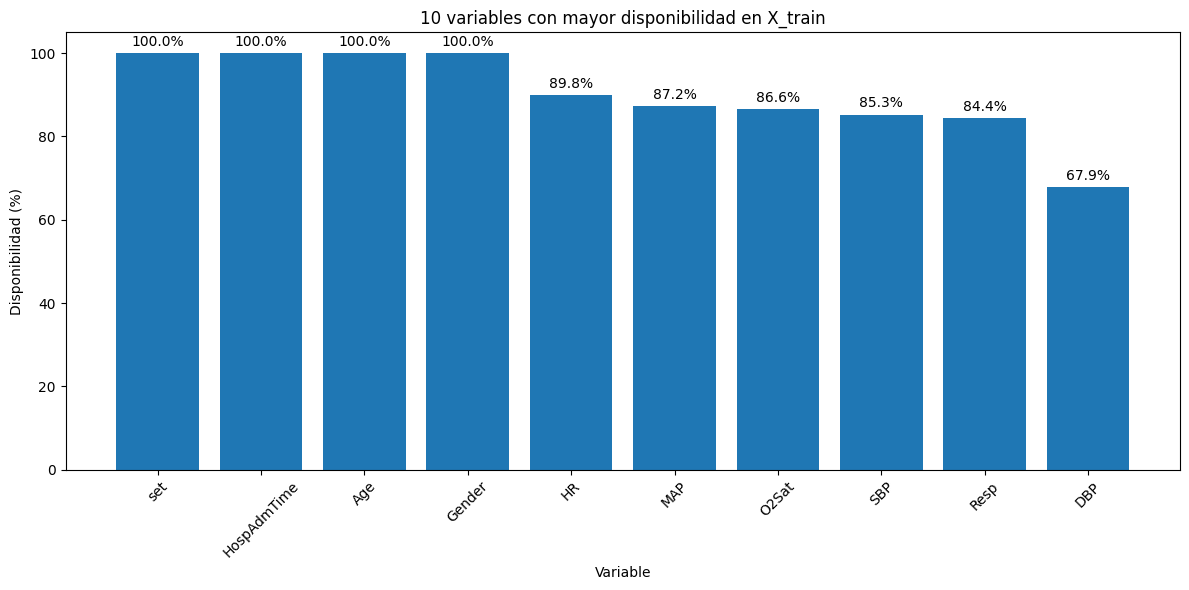

In [20]:
availability_top_10 = variable_summary.sort_values(
    "% disponibilidad", ascending=False
).head(10)["% disponibilidad"]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(availability_top_10.index, availability_top_10.values, color="#1f77b4")
ax.set_title("10 variables con mayor disponibilidad en X_train")
ax.set_xlabel("Variable")
ax.set_ylabel("Disponibilidad (%)")
ax.set_ylim(0, 105)
ax.bar_label(bars, labels=[f"{value:.1f}%" for value in availability_top_10], padding=3)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

### Funcion Beta para variables significativas

- `HR` (Heart Rate / Frecuencia Cardíaca)
- `MAP` (Mean Arterial Pressure / Presión Arterial Media)
- `O2Sat` (Oxygen Saturation / Saturación de Oxígeno)
- `SBP` (Systolic Blood Pressure / Presión Arterial Sistólica)
- `Resp` (Respiration Rate / Frecuencia Respiratoria)
- `DBP` (Diastolic Blood Pressure / Presión Arterial Diastólica)
- `Temp` (Temperature / Temperatura)


In [23]:
vitals = ["HR", "MAP", "O2Sat", "SBP", "Resp", "DBP", "Temp"]
results = {}

for col in vitals:
    data_clean = X_train[col].dropna()
    α, β, data_clean, _, col_min, col_max = beta_distribution(data_clean, EPS=1e-6)

    results[col] = {
        "α": α,
        "β": β,
        "Mínimo Original": col_min,
        "Máximo Original": col_max,
        "Observaciones No Nulas": len(data_clean),
        "% Disponibilidad": (len(data_clean) / len(X_train)) * 100,
    }

df_results = pd.DataFrame(results).T
df_results

,α,β,Mínimo Original,Máximo Original,Observaciones No Nulas,% Disponibilidad
HR,10.236907,31.135223,20.0,280.0,1008302.0,89.842546
MAP,11.394786,39.826789,20.0,300.0,979023.0,87.233705
O2Sat,7.881105,0.275256,20.0,100.0,972253.0,86.630479
SBP,12.446566,20.753380,20.0,296.0,957004.0,85.271750
Resp,9.386031,43.394863,1.0,100.0,947102.0,84.389454
DBP,8.318394,44.867375,20.0,300.0,762126.0,67.907572
Temp,189.440781,153.773420,20.9,50.0,380338.0,33.889186


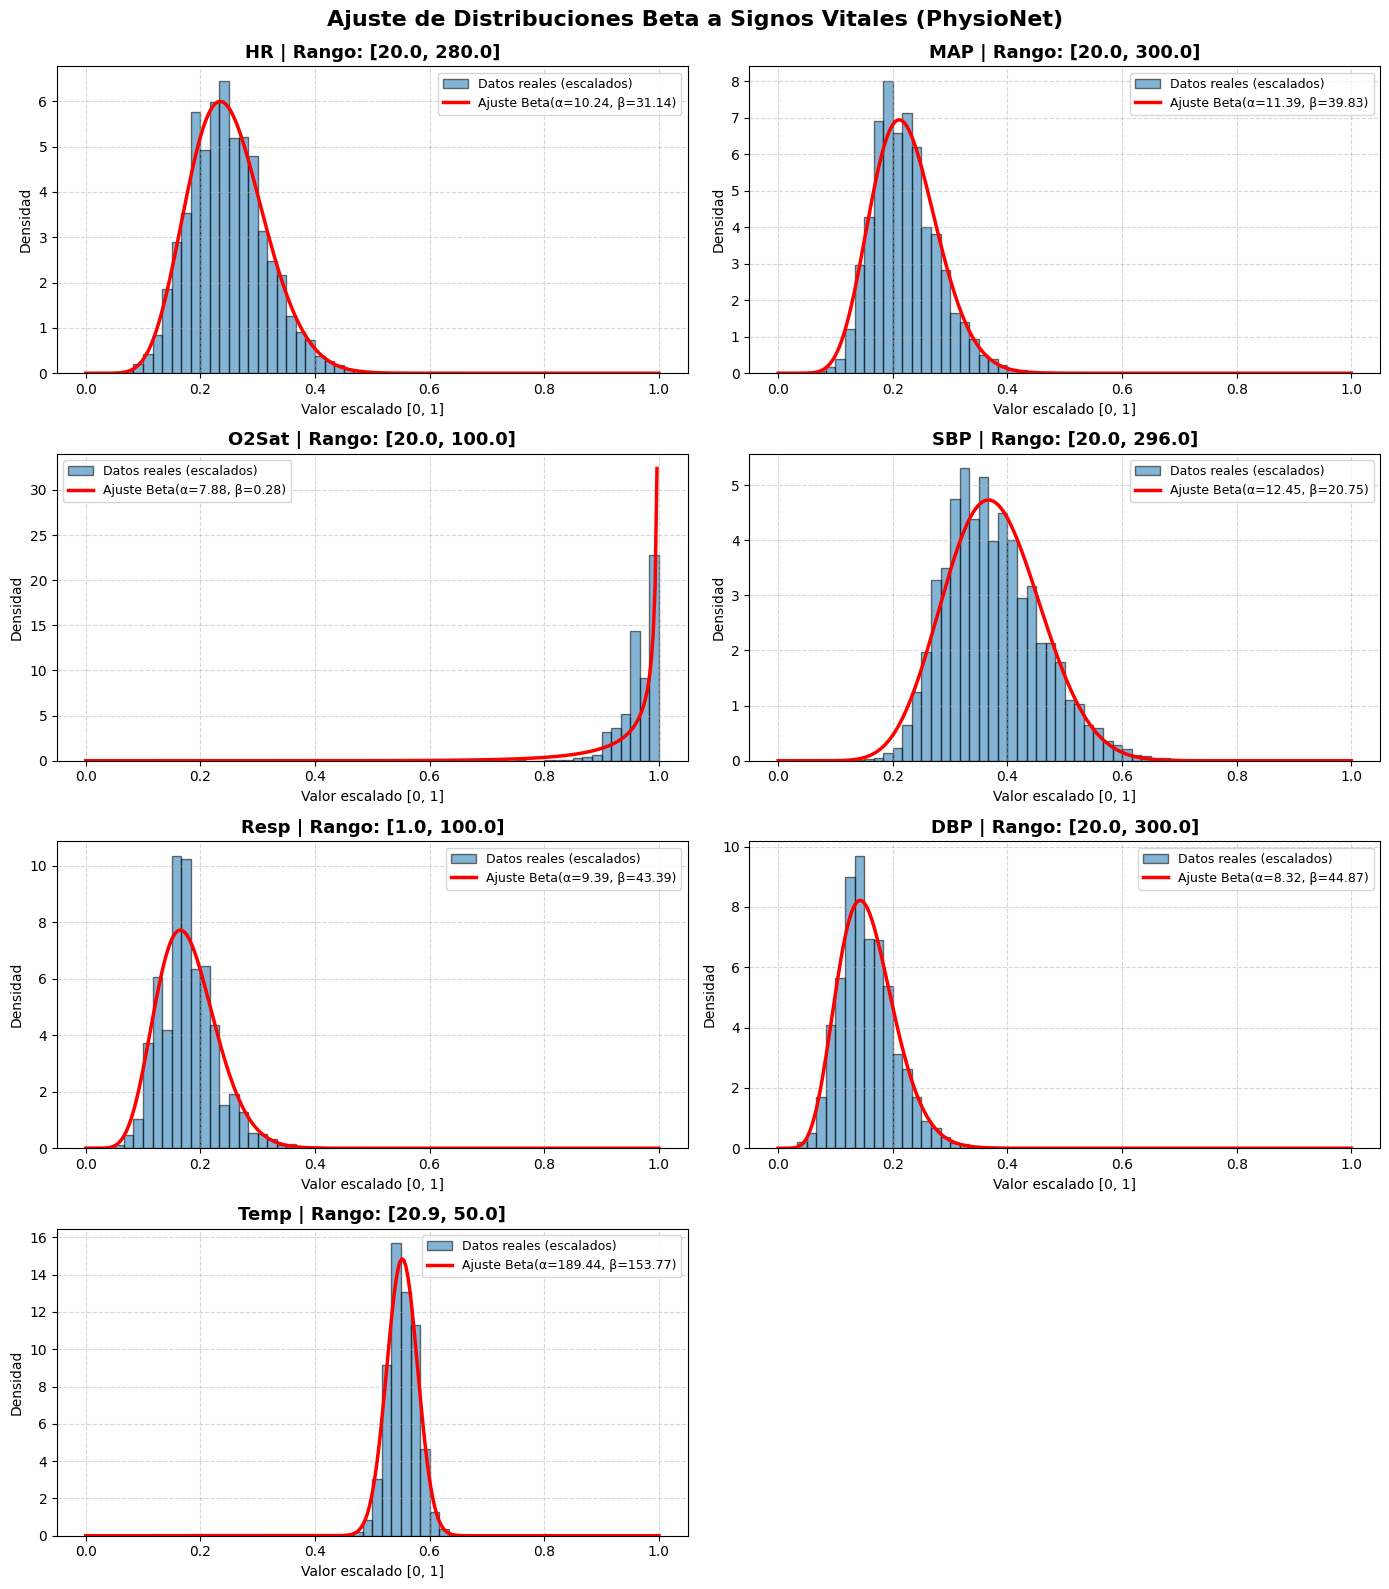

In [24]:
df_vitals = X_train[vitals].apply(
    lambda column: pd.to_numeric(column.astype(object), errors="coerce")
)
ncols = 2
nrows = (len(vitals) + ncols - 1) // ncols
fig = plot_beta_distributions(df_vitals, vitals, nrows=nrows, ncols=ncols)

# Experimento controlado de recuperación del AUC

El experimento modifica **una sola variable**. Para elegir otra, cambia únicamente `DRIFT_FEATURE` en la siguiente celda por uno de los nombres de `vitals`. El modelo base se entrena con datos limpios y permanece congelado durante la evaluación con drift y la corrección.

`MAX_TRAIN_ROWS` limita el costo del PoC conservando la proporción de clases. Usa `None` si deseas entrenar con todo `X_train`.


In [128]:
from darl.data.preprocessing import prepare_model_frame, select_training_sample
from darl.drift.injector import DriftInjector
from darl.evaluation.model_metrics import evaluate_auc
from darl.pipeline.xgboost_pipeline import make_xgb_pipeline
from darl.actions.selective_update import (
    apply_reference_location_scale_map,
    apply_reference_quantile_map,
    fit_reference_location_scale_map,
    fit_reference_quantile_map,
)

In [105]:
# vitals = ["HR", "MAP", "O2Sat", "SBP", "Resp", "DBP", "Temp"]

RANDOM_STATE = 42
DRIFT_FEATURE = "O2Sat"  # <-- CAMBIA AQUÍ la única variable que sufrirá drift
DRIFT_SEVERITY = 0.70
DRIFT_DIRECTION = "high"  # Opciones: high, low, central, extreme
MAX_TRAIN_ROWS = None  # Usa None para entrenar con todo X_train

if DRIFT_FEATURE not in vitals:
    raise ValueError(f"DRIFT_FEATURE debe ser una de estas variables: {vitals}")

print(f"Variable seleccionada: {DRIFT_FEATURE}")
print(f"Severidad: {DRIFT_SEVERITY:.0%} | Dirección: {DRIFT_DIRECTION}")

Variable seleccionada: O2Sat
Severidad: 70% | Dirección: high


### Preparación de datos y XGBoost

Las variables significativas se convierten explícitamente a numéricas para evitar que una categoría de pandas llegue al inyector. Las demás variables categóricas se imputan y codifican dentro del `Pipeline`, por lo que el mismo preprocesamiento aprendido se usa en todas las evaluaciones.


In [60]:
X_train_model = prepare_model_frame(X_train, vitals)
X_test_model = prepare_model_frame(X_test, vitals)
X_fit_clean, y_fit = select_training_sample(
    X_train_model, y_train, MAX_TRAIN_ROWS, RANDOM_STATE
)

print(f"Entrenamiento: {len(X_fit_clean):,} filas")
print(f"Evaluación: {len(X_test_model):,} filas")

Entrenamiento: 1,122,299 filas
Evaluación: 140,288 filas


### Covariate shift en una sola variable

El inyector se ajusta únicamente con `[DRIFT_FEATURE]`. Las etiquetas no se modifican: esto es covariate shift, no label shift. La aserción comprueba que ninguna otra columna haya cambiado.


In [111]:
drift_injector = DriftInjector(random_state=RANDOM_STATE).fit(
    X_fit_clean, numeric_cols=[DRIFT_FEATURE]
)
drift_config = {DRIFT_FEATURE: DRIFT_DIRECTION}

X_fit_drifted, train_drift_metadata = drift_injector.transform(
    X_fit_clean,
    drift_severity=DRIFT_SEVERITY,
    numeric_drift_config=drift_config,
    drift_type="covariate",
)
X_test_drifted, test_drift_metadata = drift_injector.transform(
    X_test_model,
    drift_severity=DRIFT_SEVERITY,
    numeric_drift_config=drift_config,
    drift_type="covariate",
)

unchanged_columns = X_test_model.columns.difference([DRIFT_FEATURE])
assert X_test_model[unchanged_columns].equals(X_test_drifted[unchanged_columns])
display(DriftInjector.summary(test_drift_metadata))

,type,drift_severity,direction,beta_orig,beta_target,ks_stat,ks_pval,psi
variable,,,,,,,,
HR,numeric,0.7,high,"(10.24, 31.14)","(5.00, 2.00)",0.660322,0.0,2.399409
MAP,numeric,0.7,high,"(11.39, 39.83)","(5.00, 2.00)",0.670829,0.0,5.238274
O2Sat,numeric,0.7,high,"(7.88, 0.28)","(5.00, 2.00)",0.612800,0.0,3.270931
SBP,numeric,0.7,high,"(12.45, 20.75)","(5.00, 2.00)",0.573075,0.0,3.600558
Resp,numeric,0.7,high,"(9.39, 43.39)","(5.00, 2.00)",0.681694,0.0,6.394860
DBP,numeric,0.7,high,"(8.32, 44.87)","(5.00, 2.00)",0.684345,0.0,6.158816
Temp,numeric,0.7,high,"(189.44, 153.77)","(5.00, 2.00)",0.520365,0.0,1.327287


### Distribución antes y después del drift

El gráfico compara la distribución de la única variable intervenida en el conjunto de evaluación, antes y después de aplicar el covariate shift.


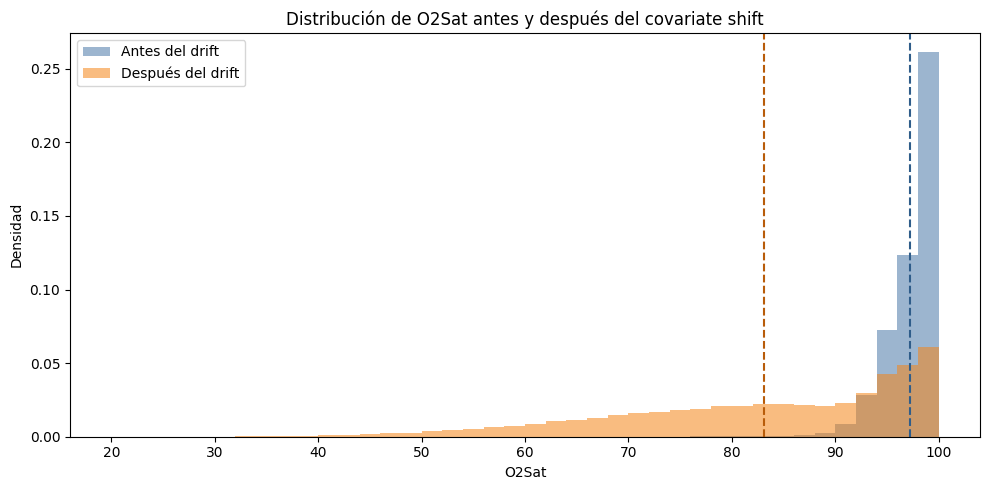

In [113]:
clean_values = X_test_model[DRIFT_FEATURE].dropna()
drifted_values = X_test_drifted[DRIFT_FEATURE].dropna()
bin_edges = np.histogram_bin_edges(pd.concat([clean_values, drifted_values]), bins=40)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    clean_values,
    bins=bin_edges,
    density=True,
    alpha=0.55,
    color="#4C78A8",
    label="Antes del drift",
)
ax.hist(
    drifted_values,
    bins=bin_edges,
    density=True,
    alpha=0.55,
    color="#F58518",
    label="Después del drift",
)
ax.axvline(clean_values.mean(), color="#2F5D8A", linestyle="--", linewidth=1.5)
ax.axvline(drifted_values.mean(), color="#B85C0A", linestyle="--", linewidth=1.5)
ax.set_title(f"Distribución de {DRIFT_FEATURE} antes y después del covariate shift")
ax.set_xlabel(DRIFT_FEATURE)
ax.set_ylabel("Densidad")
ax.legend()
fig.tight_layout()
plt.show()

### Entrenamiento, degradación y corrección

Se comparan cuatro escenarios:

1. XGBoost base entrenado y evaluado sin drift.
2. El mismo XGBoost **congelado** evaluado con drift.
3. El mismo XGBoost **congelado** después de corregir solo la variable afectada mediante un mapeo cuantílico hacia la distribución de entrenamiento limpia.
4. Otro XGBoost entrenado después del drift, incluido únicamente como referencia.


In [108]:
# 1) Modelo original entrenado con datos limpios.
frozen_model = make_xgb_pipeline(X_fit_clean, y_fit, random_state=RANDOM_STATE)
frozen_model.fit(X_fit_clean, y_fit)
auc_baseline = evaluate_auc(frozen_model, X_test_model, y_test)

# 2) El mismo modelo, sin fit adicional, recibe datos con drift.
auc_drifted = evaluate_auc(frozen_model, X_test_drifted, y_test)

# 3) Se aprende la corrección sin etiquetas y el modelo continúa congelado.
quantile_map = fit_reference_quantile_map(
    source_df=X_fit_drifted,
    reference_df=X_fit_clean,
    cols=[DRIFT_FEATURE],
)
if DRIFT_FEATURE not in quantile_map:
    raise ValueError(f"No se pudo aprender el mapeo para {DRIFT_FEATURE}.")
X_test_corrected = apply_reference_quantile_map(X_test_drifted, quantile_map)
auc_corrected = evaluate_auc(frozen_model, X_test_corrected, y_test)

# 4) Modelo nuevo entrenado con los datos que ya sufrieron drift (referencia).
drift_retrained_model = make_xgb_pipeline(
    X_fit_drifted, y_fit, random_state=RANDOM_STATE
)
drift_retrained_model.fit(X_fit_drifted, y_fit)
auc_retrained = evaluate_auc(drift_retrained_model, X_test_drifted, y_test)

In [109]:
def auc_recovery(auc_after_action, auc_drift, auc_clean):
    """Return the percentage of drift-induced AUC loss recovered."""
    lost_auc = auc_clean - auc_drift
    if lost_auc <= 0:
        return np.nan
    return 100 * (auc_after_action - auc_drift) / lost_auc


results = pd.DataFrame(
    {
        "Escenario": [
            "Base sin drift",
            "Modelo congelado + drift",
            "Modelo congelado + corrección",
            "Reentrenado después del drift",
        ],
        "AUC": [auc_baseline, auc_drifted, auc_corrected, auc_retrained],
    }
)
results["Cambio vs. base"] = results["AUC"] - auc_baseline
results["Recuperación del AUC (%)"] = [
    np.nan,
    0.0 if auc_baseline > auc_drifted else np.nan,
    auc_recovery(auc_corrected, auc_drifted, auc_baseline),
    auc_recovery(auc_retrained, auc_drifted, auc_baseline),
]
display(
    results.style.format(
        {
            "AUC": "{:.4f}",
            "Cambio vs. base": "{:+.4f}",
            "Recuperación del AUC (%)": "{:.1f}",
        }
    )
)

,Escenario,AUC,Cambio vs. base,Recuperación del AUC (%)
0,Base sin drift,0.7776,+0.0000,nan
1,Modelo congelado + drift,0.7526,-0.0250,0.0
2,Modelo congelado + corrección,0.7692,-0.0084,66.4
3,Reentrenado después del drift,0.7789,+0.0013,105.0


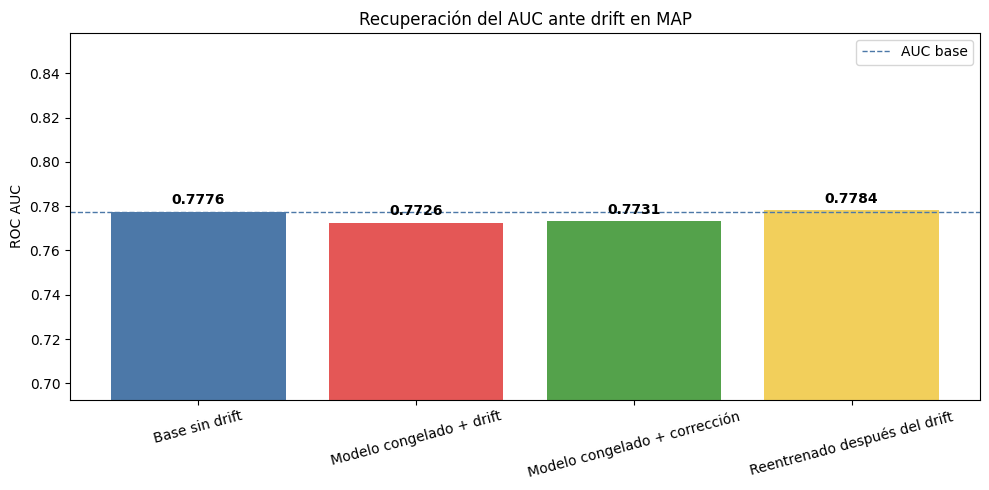

In [104]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    results["Escenario"],
    results["AUC"],
    color=["#4C78A8", "#E45756", "#72B7B2", "#54A24B", "#F2CF5B"],
)
ax.axhline(
    float(auc_baseline), color="#4C78A8", linestyle="--", linewidth=1, label="AUC base"
)
ax.bar_label(
    bars,
    labels=[f"{value:.4f}" for value in results["AUC"]],
    padding=3,
    fontweight="bold",
)
ax.set_ylim(max(0, results["AUC"].min() - 0.08), min(1.0, results["AUC"].max() + 0.08))
ax.set_ylabel("ROC AUC")
ax.set_title(f"Recuperación del AUC ante drift en {DRIFT_FEATURE}")
ax.tick_params(axis="x", rotation=15)
ax.legend()
fig.tight_layout()
plt.show()

### Interpretación

La recuperación se calcula sobre el AUC que realmente se perdió por el drift: `(AUC_corregido - AUC_drift) / (AUC_base - AUC_drift) × 100`. Un 100 % indica recuperación total; entre 0 % y 100 %, recuperación parcial; un valor negativo, deterioro adicional; y más de 100 %, mejora por encima del baseline. Si el drift no reduce el AUC, la recuperación queda indefinida (`NaN`) porque no existe una pérdida que recuperar.


# Experimento A2: varios métodos de feature updating

Las siete variables clínicas sufren el mismo **Beta-drift**. A2 no entrena clasificadores, redes ni calibradores: solo estima estadísticas no supervisadas de `X_fit_drifted` y las alinea con `X_fit_clean`; el XGBoost entrenado con los datos limpios permanece congelado. `y_test` aparece únicamente al final para medir el AUC, por lo que no selecciona el método. El reentrenamiento se muestra al final solo como referencia A3.

Se comparan tres transformaciones de preprocesamiento: (1) media–desviación estándar, adecuada si el cambio es aproximadamente afín; (2) mediana–IQR, robusta ante contaminación por valores extremos; y (3) mapeo cuantílico marginal, no paramétrico. De acuerdo con Zliobaite–Gabrys, este bloque corresponde a adaptación de preprocesamiento ante _virtual drift_ / evolución de datos, no a un cambio de concepto.

> Nota metodológica: el inyector Beta reemplaza valores de filas individuales. Por ello, ninguna corrección marginal puede garantizar recuperar el AUC; una recuperación baja indica que el drift destruyó información por fila, no que A2 deba entrenar otro predictor. Para el requisito de recuperación garantizada se debe añadir un escenario separado de drift de medición reversible.


In [137]:
vitals = ["HR", "MAP", "O2Sat", "SBP", "Resp", "DBP", "Temp"]

RANDOM_STATE = 42
DRIFT_SEVERITY = 0.30
DRIFT_DIRECTION = "extreme"  # Opciones: high, low, central, extreme
MAX_TRAIN_ROWS = None  # Usa None para entrenar con todo X_train


drift_injector = DriftInjector(random_state=RANDOM_STATE).fit(
    X_fit_clean, numeric_cols=vitals
)
drift_config = {vital: DRIFT_DIRECTION for vital in vitals}

X_fit_drifted, train_drift_metadata = drift_injector.transform(
    X_fit_clean,
    drift_severity=DRIFT_SEVERITY,
    numeric_drift_config=drift_config,
    drift_type="covariate",
)
X_test_drifted, test_drift_metadata = drift_injector.transform(
    X_test_model,
    drift_severity=DRIFT_SEVERITY,
    numeric_drift_config=drift_config,
    drift_type="covariate",
)

unchanged_columns = X_test_model.columns.difference(vitals)
display(DriftInjector.summary(test_drift_metadata))

,type,drift_severity,direction,beta_orig,beta_target,ks_stat,ks_pval,psi
variable,,,,,,,,
HR,numeric,0.3,extreme,"(10.24, 31.14)","(0.50, 0.50)",0.163440,0.0,0.460221
MAP,numeric,0.3,extreme,"(11.39, 39.83)","(0.50, 0.50)",0.170726,0.0,1.084476
O2Sat,numeric,0.3,extreme,"(7.88, 0.28)","(0.50, 0.50)",0.267368,0.0,1.275863
SBP,numeric,0.3,extreme,"(12.45, 20.75)","(0.50, 0.50)",0.133052,0.0,1.220370
Resp,numeric,0.3,extreme,"(9.39, 43.39)","(0.50, 0.50)",0.184890,0.0,1.063076
DBP,numeric,0.3,extreme,"(8.32, 44.87)","(0.50, 0.50)",0.187844,0.0,1.045985
Temp,numeric,0.3,extreme,"(189.44, 153.77)","(0.50, 0.50)",0.147152,0.0,0.516607


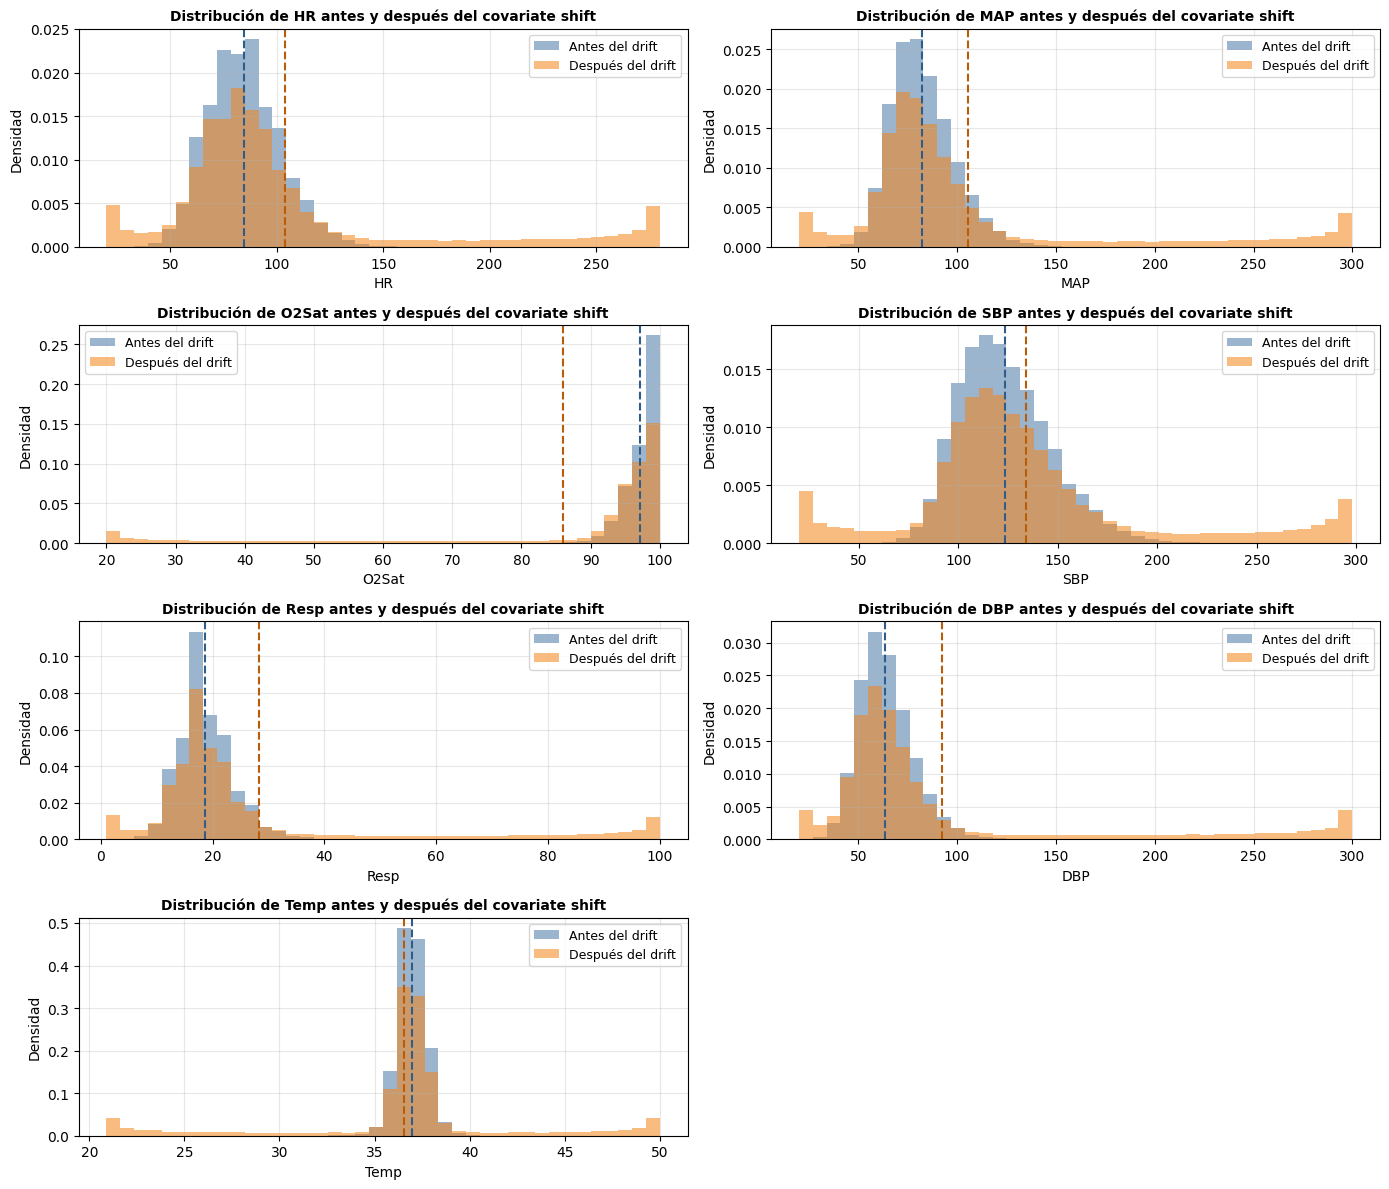

In [138]:
# Crear subplots para todas las variables
ncols = 2
nrows = (len(vitals) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 12))
axes = axes.flatten()  # Aplanar el array de ejes para facilitar la iteración

for idx, vital in enumerate(vitals):
    ax = axes[idx]

    # Obtener valores limpios y con drift para esta variable
    clean_values = X_test_model[vital].dropna()
    drifted_values = X_test_drifted[vital].dropna()

    # Calcular bordes de bins consistentes
    bin_edges = np.histogram_bin_edges(
        pd.concat([clean_values, drifted_values]), bins=40
    )

    # Crear histogramas superpuestos
    ax.hist(
        clean_values,
        bins=bin_edges,
        density=True,
        alpha=0.55,
        color="#4C78A8",
        label="Antes del drift",
    )
    ax.hist(
        drifted_values,
        bins=bin_edges,
        density=True,
        alpha=0.55,
        color="#F58518",
        label="Después del drift",
    )

    # Líneas de media
    ax.axvline(clean_values.mean(), color="#2F5D8A", linestyle="--", linewidth=1.5)
    ax.axvline(drifted_values.mean(), color="#B85C0A", linestyle="--", linewidth=1.5)

    # Etiquetado
    ax.set_title(
        f"Distribución de {vital} antes y después del covariate shift",
        fontsize=10,
        fontweight="bold",
    )
    ax.set_xlabel(vital)
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Ocultar ejes sobrantes
for idx in range(len(vitals), len(axes)):
    axes[idx].set_visible(False)

fig.tight_layout()
plt.show()

In [ ]:
# El único fit de un clasificador ocurre aquí, antes del drift.
frozen_model = make_xgb_pipeline(X_fit_clean, y_fit, random_state=RANDOM_STATE)
frozen_model.fit(X_fit_clean, y_fit)
auc_baseline = evaluate_auc(frozen_model, X_test_model, y_test)
auc_drifted = evaluate_auc(frozen_model, X_test_drifted, y_test)

# A2.1: alineación paramétrica de media y desviación estándar.
standard_map = fit_reference_location_scale_map(
    X_fit_drifted, X_fit_clean, vitals, robust=False
)
X_test_standard = apply_reference_location_scale_map(X_test_drifted, standard_map)

# A2.2: misma alineación, usando mediana e IQR para resistir outliers.
robust_map = fit_reference_location_scale_map(
    X_fit_drifted, X_fit_clean, vitals, robust=True
)
X_test_robust = apply_reference_location_scale_map(X_test_drifted, robust_map)

# A2.3: alineación no paramétrica de cuantiles marginales.
quantile_map = fit_reference_quantile_map(
    source_df=X_fit_drifted, reference_df=X_fit_clean, cols=vitals
)
X_test_quantile = apply_reference_quantile_map(X_test_drifted, quantile_map)

# Cada variante usa el mismo XGBoost congelado; no intervienen etiquetas en A2.
auc_standard = evaluate_auc(frozen_model, X_test_standard, y_test)
auc_robust = evaluate_auc(frozen_model, X_test_robust, y_test)
auc_quantile = evaluate_auc(frozen_model, X_test_quantile, y_test)

# A3 (referencia): reentrenamiento con etiquetas después del drift.
# No forma parte de feature updating ni interviene en la selección de A2.
drift_retrained_model = make_xgb_pipeline(
    X_fit_drifted, y_fit, random_state=RANDOM_STATE
)
drift_retrained_model.fit(X_fit_drifted, y_fit)
auc_retrained = evaluate_auc(drift_retrained_model, X_test_drifted, y_test)

results = pd.DataFrame(
    {
        "Escenario": [
            "Base sin drift",
            "Congelado + Beta-drift",
            "A2: media–desviación",
            "A2: mediana–IQR",
            "A2: mapeo cuantílico",
            "A3: reentrenado post-drift",
        ],
        "AUC": [
            auc_baseline,
            auc_drifted,
            auc_standard,
            auc_robust,
            auc_quantile,
            auc_retrained,
        ],
    }
)
results["Cambio vs. base"] = results["AUC"] - auc_baseline
results["Recuperación del AUC (%)"] = [
    np.nan,
    0.0 if auc_baseline > auc_drifted else np.nan,
    *[auc_recovery(auc, auc_drifted, auc_baseline) for auc in results["AUC"].iloc[2:]],
]
display(
    results.style.format(
        {
            "AUC": "{:.4f}",
            "Cambio vs. base": "{:+.4f}",
            "Recuperación del AUC (%)": "{:.1f}",
        }
    )
)

,Escenario,AUC,Cambio vs. base,Recuperación del AUC (%)
0,Base sin drift,0.7776,+0.0000,nan
1,Congelado + Beta-drift,0.6380,-0.1396,0.0
2,A2: media–desviación,0.6718,-0.1058,24.2
3,A2: mediana–IQR,0.6874,-0.0902,35.4
4,A2: mapeo cuantílico,0.6816,-0.0960,31.2
5,A3: reentrenado post-drift,0.7385,-0.0391,72.0


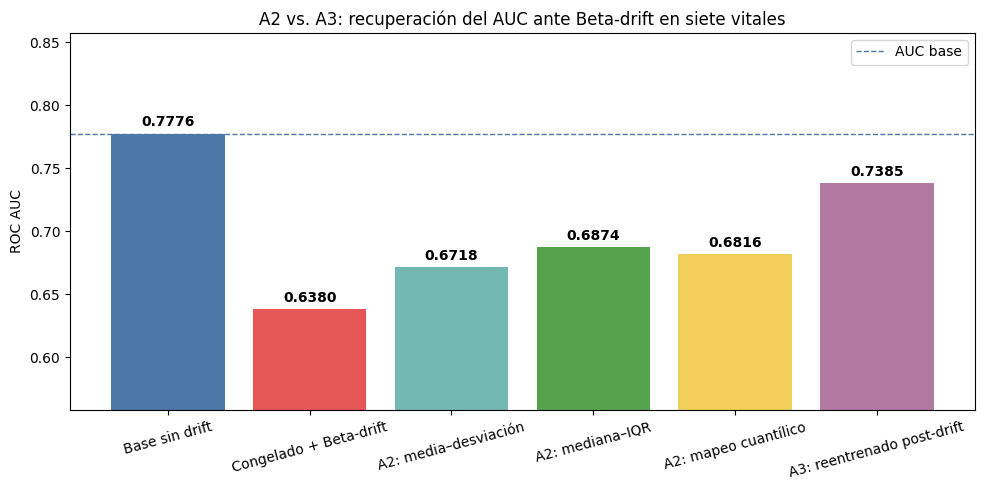

In [132]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    results["Escenario"],
    results["AUC"],
    color=["#4C78A8", "#E45756", "#72B7B2", "#54A24B", "#F2CF5B", "#B279A2"],
)
ax.axhline(
    float(auc_baseline), color="#4C78A8", linestyle="--", linewidth=1, label="AUC base"
)
ax.bar_label(
    bars,
    labels=[f"{value:.4f}" for value in results["AUC"]],
    padding=3,
    fontweight="bold",
)
ax.set_ylim(max(0, results["AUC"].min() - 0.08), min(1.0, results["AUC"].max() + 0.08))
ax.set_ylabel("ROC AUC")
ax.set_title("A2 vs. A3: recuperación del AUC ante Beta-drift en siete vitales")
ax.tick_params(axis="x", rotation=15)
ax.legend()
fig.tight_layout()
plt.show()